# Lesson 1.1: ML Piplines with ZenML
Key Concepts ML Piplines, Steps
In this notebook, we will learn how to easily convert existing ML code into ML piplines ZenML


 ZenML sklearn integration
 install ZenML and sklearn

In [28]:
# pip install "zenml[server]"
!zenml integration install sklearn -y
# pip install pyparsing==2.4.2

⠋ Installing integrations...
⠋ Installing integrations...
⠙ Installing integrations...
⠸ Installing integrations...
⠼ Installing integrations...
⠴ Installing integrations...
⠦ Installing integrations...
⠧ Installing integrations...
⠇ Installing integrations...
⠏ Installing integrations...
⠋ Installing integrations...
⠙ Installing integrations...
⠹ Installing integrations...
⠸ Installing integrations...
⠼ Installing integrations...
⠦ Installing integrations...
⠧ Installing integrations...
⠧ Installing integrations...
⠏ Installing integrations...
⠋ Installing integrations...
⠙ Installing integrations...
⠹ Installing integrations...
⠸ Installing integrations...
⠼ Installing integrations...
⠴ Installing integrations...
⠦ Installing integrations...
⠧ Installing integrations...
⠇ Installing integrations...
⠋ Installing integrations...
⠙ Installing integrations...
⠙ Installing integrations...



# ZenML Setup

In [29]:
!rm -rf .zen
!zenml init

'rm' n'est pas reconnu en tant que commande interne
ou externe, un programme ex�cutable ou un fichier de commandes.


Found existing ZenML repository at path 
'c:\Users\zitou\OneDrive\Documents\python\Courses\MLOpd\project'.
⠋ Initializing ZenML repository at 
c:\Users\zitou\OneDrive\Documents\python\Courses\MLOpd\project.

⠋ Initializing ZenML repository at 
c:\Users\zitou\OneDrive\Documents\python\Courses\MLOpd\project.




# Example Experimentation ML Code
We train a Scikit-learn SVC classifier to classify images of handwritten digits.

In [30]:
import numpy as np
from sklearn.base import ClassifierMixin
from sklearn.svm import SVC
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

def train_test() -> None:
    """Train and test a Scikit-learn SVC classifier on digits"""
    digits=load_digits()
    data=digits.images.reshape((len(digits.images),-1))
    X_train,X_test,y_train,y_test=train_test_split(
        data,digits.target,test_size=0.2,shuffle=False
    )
    model=SVC(gamma=0.001)
    model.fit(X_train,y_train)
    test_acc=model.score(X_test,y_test)
    print(f"Test accurancy : {test_acc}")

train_test()

Test accurancy : 0.9583333333333334


# Turning experiments into ML piplines with ZenML
we can identify three distinct steps in our example: data loading,model training, and model evaluation.Let us now define each of them as a ZenML Pipline Step simply by moving each step to its own function and decoration them with ZenML's @step python decoration 

In [31]:
from zenml import step
from typing_extensions import Annotated
import pandas as pd
import numpy as np
from typing import Tuple

@step
def importer()->Tuple[
    Annotated[np.ndarray,"X_train"],
    Annotated[np.ndarray,"X_test"],
    Annotated[np.ndarray,"y_train"],
    Annotated[np.ndarray,"y_test"],
]:
    """Load the digits dataset as numpy arrays."""
    digits=load_digits()
    data=digits.images.reshape((len(digits.images),-1))
    X_train,X_test,y_train,y_test=train_test_split(
        data,digits.target,test_size=0.2,shuffle=False
    )
    return X_train,X_test,y_train,y_test

@step
def svc_trainer(
    X_train:np.ndarray,
    y_train:np.ndarray
)-> ClassifierMixin:
    "Train an sklearn SVC classifier."
    model=SVC(gamma=0.001)
    model.fit(X_train,y_train)
    return model

@step
def evaluator(
    X_test:np.ndarray,
    y_test:np.ndarray,
    model:ClassifierMixin,
)-> float:
    """Calculate the test set accuracy of an sklearn model."""
    test_acc=model.score(X_test,y_test)
    print(f"Test accurancy: {test_acc}")
    return test_acc

Similarily, we can use ZenML's @pipline decorator to connect all of our steps into an ML pipline.
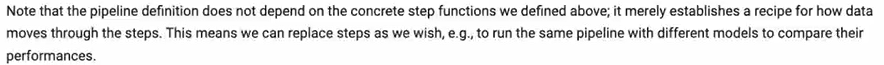

In [32]:
from zenml import pipeline
@pipeline 
def digits_pipline():
    """Links all the steps together in a pipline"""
    X_train,X_test,y_train,y_test=importer()
    model=svc_trainer(X_train=X_train,y_train=y_train)
    evaluator(X_test=X_test,y_test=y_test,model=model)

# Running ZenML Piplines
Finally,we initialize our pipeline with concrete step functions and call the run() method to run it

In [33]:
digits_svc_pipeline=digits_pipline()
# digits_svc_pipeline.run(unlisted=True)

Initiating a new run for the pipeline: digits_pipline.
Executing a new run.
Using user: default
Using stack: default
  artifact_store: default
  orchestrator: default
You can visualize your pipeline runs in the ZenML Dashboard. In order to try it locally, please run zenml up.
Using cached version of importer.
Step importer has started.
Using cached version of svc_trainer.
Step svc_trainer has started.
Using cached version of evaluator.
Step evaluator has started.
Pipeline run has finished in 2.208s.


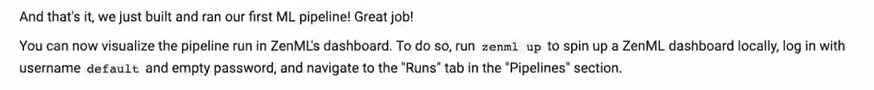

In [34]:
# from zenml.environment import Environment


# def start_zenml_dashboard(port=8081):
#     # Start the ZenML dashboard on the specified port
#     !zenml up --blocking --port {port}

# # Call the function to start the dashboard
# start_zenml_dashboard()

# zenml up --blocking --port 8081



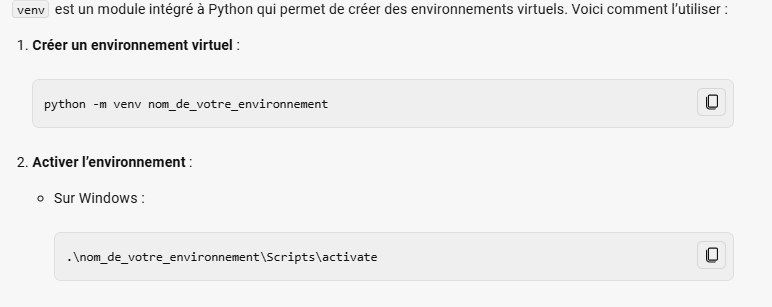
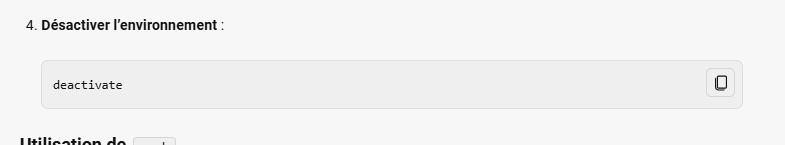